In [4]:
import numpy as np
from scipy import odr
import matplotlib.pyplot as plt

## Fitting with Asymmetric Errors

In [ ]:
def polyfit_with_asym_errors(x, y, unc_lower, unc_upper, n_iterations=1000, x_range=None, deg=1, semilog=False):
    """
    Perform bootstrap/Monte Carlo fitting accounting for asymmetric uncertainties.
     - For each iteration, randomly sample from the asymmetric uncertainties to create a new y dataset.
     - Fit a polynomial to this new dataset and store the coefficients.
     - After all iterations, calculate the median fit and the 16th/84th percentiles to represent the uncertainty band.
     
    Returns:
        fit_params: Array of fitted coefficients for each bootstrap iteration
        (x_fit, y_fit, y_fits, y_lower, y_upper): Tuple containing:
            x_fit: x-values for the fit line
            y_fit: Best fit line without uncertainties
            y_fits: Array of fit lines for each bootstrap iteration
            y_lower: 16th percentile of the fit lines (lower bound of uncertainty)
            y_upper: 84th percentile of the fit lines (upper bound of uncertainty)
    """
    n_points = len(x)
    fit_params = []
    
    # Transform x to log space
    if semilog:
        x_fitspace = np.log10(x)
    else:
        x_fitspace = x.copy()
    
    for _ in range(int(n_iterations)):
        # Randomly sample from asymmetric uncertainties
        y_samples = np.zeros(n_points)
        for i in range(n_points):
            # Sample from appropriate side based on sign
            if np.random.rand() < 0.5:
                y_samples[i] = y[i] - np.abs(np.random.normal(0, unc_lower[i]))
            else:
                y_samples[i] = y[i] + np.abs(np.random.normal(0, unc_upper[i]))
        
        # Fit this bootstrap sample
        coeffs_boot = np.polyfit(x_fitspace, y_samples, deg=deg)
        fit_params.append(coeffs_boot)
    
    fit_params = np.array(fit_params)
    
    # Create x_fit in linear/log space
    if semilog:
        if x_range is None:
            x_fit = np.logspace(np.log10(x.min()) - 0.2, np.log10(x.max()) + 0.2, 1000)
        else:
            x_fit = np.logspace(np.log10(x_range[0]), np.log10(x_range[1]), 1000)
        x_eval = np.log10(x_fit)
    else:
        if x_range is None:
            x_fit = np.linspace(x.min() - 0.5, x.max() + 0.5, 1000)
        else:
            x_fit = np.linspace(x_range[0], x_range[1], 1000)
        x_eval = x_fit

    # Evaluate polynomial
    y_fit = np.polyval(np.median(fit_params, axis=0), x_eval)
    y_fits = np.array([np.polyval(params, x_eval) for params in fit_params])
    y_lower = np.percentile(y_fits, 16, axis=0)
    y_upper = np.percentile(y_fits, 84, axis=0)
    
    return fit_params, (x_fit, y_fit, y_fits, y_lower, y_upper)



In [ ]:
## Test the function with some example data
test_function = True
is_data_semilog = True
if test_function:
    np.random.seed(3)

    if is_data_semilog:
        x_test = np.array([3, 30, 900, 1600, 190000]) # semilog test
    else:
        x_test = np.array([1, 3, 9, 16, 19]) # linear test
    y_test = np.array([10, 60, 20, 80, 75])
    unc_lower_test = np.array([5, 44, 15, 30, 70])
    unc_upper_test = np.array([13, 95, 32, 92, 79])

    fit_params_test, (x_fit, y_fit, y_fits, y_lower, y_upper) = polyfit_with_asym_errors(
            x_test, 
            y_test, 
            unc_lower_test, 
            unc_upper_test, 
            n_iterations=1e3, 
            deg=1,
            semilog=is_data_semilog
        )

    print("y_fits shape:", y_fits.shape)
    print("y_lower shape:", y_lower.shape)
    print("y_upper shape:", y_upper.shape)
    print("Fit coefficients (median):", np.median(fit_params_test, axis=0))
            
    ## Plot the test values
    plt.figure(figsize=(8, 6))
    plt.xscale('log' if is_data_semilog else 'linear')
    plt.errorbar(
        x_test, y_test, yerr=[unc_lower_test, unc_upper_test], 
        fmt='o', color='blue', ecolor='k', elinewidth=1, capsize=0
    )
    plt.plot(
        x_fit, y_fit, 
        color='red', linestyle='--', zorder=5,
        label='Median Fit (No Uncertainties)'
    )
    plt.fill_between(
        x_fit, y_lower, y_upper, 
        color='blue', alpha=0.2,  zorder=4,
        label=r'Bootstrap 1$\sigma$ Uncertainty'
    )

    ## Plot all the individual bootstrap fits
    for y_fit in y_fits:
        plt.plot(x_fit, y_fit, color='gray', linestyle='-', alpha=0.1)

    plt.legend()
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Test Data with Asymmetric Uncertainties')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## ODR Fitting with Asymmetric Errors

In [5]:
def polyfit_with_asym_errors_odr(
        x, x_unc_lower, x_unc_upper, 
        y, y_unc_lower, y_unc_upper, 
        n_iterations=1000, x_range=None, deg=1, semilog=False
    ):
    """
    Perform bootstrap/Monte Carlo ODR fitting accounting for asymmetric uncertainties in both x and y.
    Uses Orthogonal Distance Regression to fit in both directions.
    
    Parameters:
    -----------
    x : array
        x data
    x_unc_lower : array
        Lower uncertainties in x
    x_unc_upper : array
        Upper uncertainties in x
    y : array
        y data
    y_unc_lower : array
        Lower uncertainties in y
    y_unc_upper : array
        Upper uncertainties in y
    n_iterations : int
        Number of bootstrap iterations
    x_range : tuple or None
        Range for fit evaluation [x_min, x_max]
    deg : int
        Degree of polynomial fit
    semilog : bool
        If True, fit in log(x) space
    
    Returns:
    --------
    fit_params : array
        Array of fitted coefficients for each bootstrap iteration
    (x_fit, y_fit, y_fits, y_lower, y_upper) : tuple
        Fit results and uncertainty bands
    """
    n_points = len(x)
    fit_params = []
    
    # Define polynomial model for ODR
    def poly_func(p, x):
        """Polynomial function: p[0] + p[1]*x + p[2]*x^2 + ..."""
        return np.polyval(p, x)
    
    # Transform x to log space if needed
    if semilog:
        x_fitspace = np.log10(x)
        x_unc_lower_fitspace = x_unc_lower / (x * np.log(10)) # Error propagation for log
        x_unc_upper_fitspace = x_unc_upper / (x * np.log(10)) # Error propagation for log
    else:
        x_fitspace = x.copy()
        x_unc_lower_fitspace = x_unc_lower.copy()
        x_unc_upper_fitspace = x_unc_upper.copy()
    
    for _ in range(int(n_iterations)):
        # Randomly sample from asymmetric uncertainties in both x and y
        x_samples = np.zeros(n_points)
        y_samples = np.zeros(n_points)
        x_samples_unc = np.zeros(n_points)
        y_samples_unc = np.zeros(n_points)
        
        for i in range(n_points):
            # Sample x from asymmetric uncertainties -- the sample uncertainties would be considered as symmetric for the ODR fit, but the sampling accounts for the asymmetry
            if np.random.rand() < 0.5:
                x_samples[i] = x_fitspace[i] - np.abs(np.random.normal(0, x_unc_lower_fitspace[i]))
                x_samples_unc[i] = np.sqrt(x_unc_lower_fitspace[i]**2)
            else:
                x_samples[i] = x_fitspace[i] + np.abs(np.random.normal(0, x_unc_upper_fitspace[i]))
                x_samples_unc[i] = np.sqrt(x_unc_upper_fitspace[i]**2)
            
            # Sample y from asymmetric uncertainties -- the sample uncertainties would be considered as symmetric for the ODR fit, but the sampling accounts for the asymmetry
            if np.random.rand() < 0.5:
                y_samples[i] = y[i] - np.abs(np.random.normal(0, y_unc_lower[i]))
                y_samples_unc[i] = np.sqrt(y_unc_lower[i]**2)
            else:
                y_samples[i] = y[i] + np.abs(np.random.normal(0, y_unc_upper[i]))
                y_samples_unc[i] = np.sqrt(y_unc_upper[i]**2)
        
        # Initial guess using standard polyfit
        guess_params = np.polyfit(x_samples, y_samples, deg=deg)
        
        # Create ODR model
        model = odr.Model(poly_func)
        data = odr.RealData(x_samples, y_samples, sx=x_samples_unc, sy=y_samples_unc)
        odr_obj = odr.ODR(data, model, beta0=guess_params)
        output = odr_obj.run()
        # print(output.pprint())
        fit_params.append(output.beta)
        
    fit_params = np.array(fit_params)
    # print("Fit parameters shape:", fit_params.shape)
    
    # Create x_fit in linear/log space
    if semilog:
        if x_range is None:
            x_fit = np.logspace(np.log10(x.min()) - 0.2, np.log10(x.max()) + 0.2, 1000)
        else:
            x_fit = np.logspace(np.log10(x_range[0]), np.log10(x_range[1]), 1000)
        x_eval = np.log10(x_fit)
    else:
        if x_range is None:
            x_fit = np.linspace(x.min() - 0.5, x.max() + 0.5, 1000)
        else:
            x_fit = np.linspace(x_range[0], x_range[1], 1000)
        x_eval = x_fit

    # Evaluate polynomial
    y_median_fit = np.polyval(np.median(fit_params, axis=0), x_eval)
    y_fits = np.array([np.polyval(params, x_eval) for params in fit_params])
    y_lower = np.percentile(y_fits, 16, axis=0)
    y_upper = np.percentile(y_fits, 84, axis=0)
    
    return fit_params, (x_fit, y_median_fit, y_fits, y_lower, y_upper)

In [6]:
## Generating synthetic data
# np.random.seed(3)

test_function = True
semilog_data = True
n_iterations = 1e3
n_points = 1000

if test_function:

    # True underlying relationship: y = 2x + 10
    true_slope = 3.0
    true_intercept = 10.0

    if semilog_data:
        # semilog test: y = a*log10(x) + b
        x_test = np.logspace(0, 3, n_points)  # input exponents
        y_true = true_slope * np.log10(x_test) + true_intercept
        
        # Asymmetric uncertainties (larger at higher x)
        x_test_unc_lower = np.random.uniform(0.5, 1, n_points)
        x_test_unc_upper = np.random.uniform(0.5, 1, n_points)
        y_test_unc_lower = np.random.uniform(1, 5, n_points)
        y_test_unc_upper = np.random.uniform(1, 5, n_points)
    else:
        # Linear test: y = 2x + 10
        x_test = np.linspace(1, 20, n_points)
        y_true = true_slope * x_test + true_intercept
        
        # Asymmetric uncertainties
        x_test_unc_lower = np.random.uniform(0.5, 1, n_points)
        x_test_unc_upper = np.random.uniform(0.5, 1, n_points)
        y_test_unc_lower = np.random.uniform(1, 5, n_points)
        y_test_unc_upper = np.random.uniform(1, 5, n_points)
    
    # Generate observed data by adding noise
    y_test = np.zeros(n_points)
    for i in range(n_points):
        # Randomly sample from asymmetric uncertainties
        if np.random.rand() < 0.5:
            y_test[i] = y_true[i] - np.abs(np.random.normal(0, y_test_unc_lower[i]))
        else:
            y_test[i] = y_true[i] + np.abs(np.random.normal(0, y_test_unc_upper[i]))
    
    # Perform fit
    fit_params_test, (x_fit, y_fit, y_fits, y_lower, y_upper) = polyfit_with_asym_errors_odr(
        x_test, x_test_unc_lower, x_test_unc_upper, 
        y_test, y_test_unc_lower, y_test_unc_upper, 
        n_iterations=n_iterations, 
        deg=1,
        semilog=semilog_data
    )

    # Extract fit parameters
    median_coeffs = np.median(fit_params_test, axis=0)
    fit_slope_err = np.std(fit_params_test[:, 0])
    fit_intercept_err = np.std(fit_params_test[:, 1])

    # Get true line, median fit, and residuals
    if semilog_data:
        y_true_line = true_slope * np.log10(x_fit) + true_intercept
        y_median_fit = np.polyval(median_coeffs, np.log10(x_test))
        x_median_fit = 10**((y_test - median_coeffs[1]) / median_coeffs[0])

        # Residuals in log-space (dex)
        x_residuals_median = np.log10(x_test) - np.log10(x_median_fit)
        x_unc_lower_fit = x_test_unc_lower / (x_test * np.log(10))
        x_unc_upper_fit = x_test_unc_upper / (x_test * np.log(10))
    else:
        y_true_line = true_slope * x_fit + true_intercept
        y_median_fit = np.polyval(median_coeffs, x_test)
        x_median_fit = (y_test - median_coeffs[1]) / median_coeffs[0]
        
        # Residuals in linear space
        x_residuals_median = x_test - x_median_fit
        x_unc_lower_fit = x_test_unc_lower
        x_unc_upper_fit = x_test_unc_upper

    y_residuals_median = y_test - y_median_fit

    # Orthogonal residuals (use abs for distance, but keep sign for plotting)
    orthogonal_residuals = y_residuals_median / np.sqrt(1 + median_coeffs[0]**2)

    # Orthogonal lower uncertainty (combine x_lower and y_lower)
    ortho_unc_lower = np.sqrt(
        (median_coeffs[0] * x_unc_lower_fit)**2 + y_test_unc_lower**2
    ) / np.sqrt(1 + median_coeffs[0]**2)

    # Orthogonal upper uncertainty (combine x_upper and y_upper)
    ortho_unc_upper = np.sqrt(
        (median_coeffs[0] * x_unc_upper_fit)**2 + y_test_unc_upper**2
    ) / np.sqrt(1 + median_coeffs[0]**2)

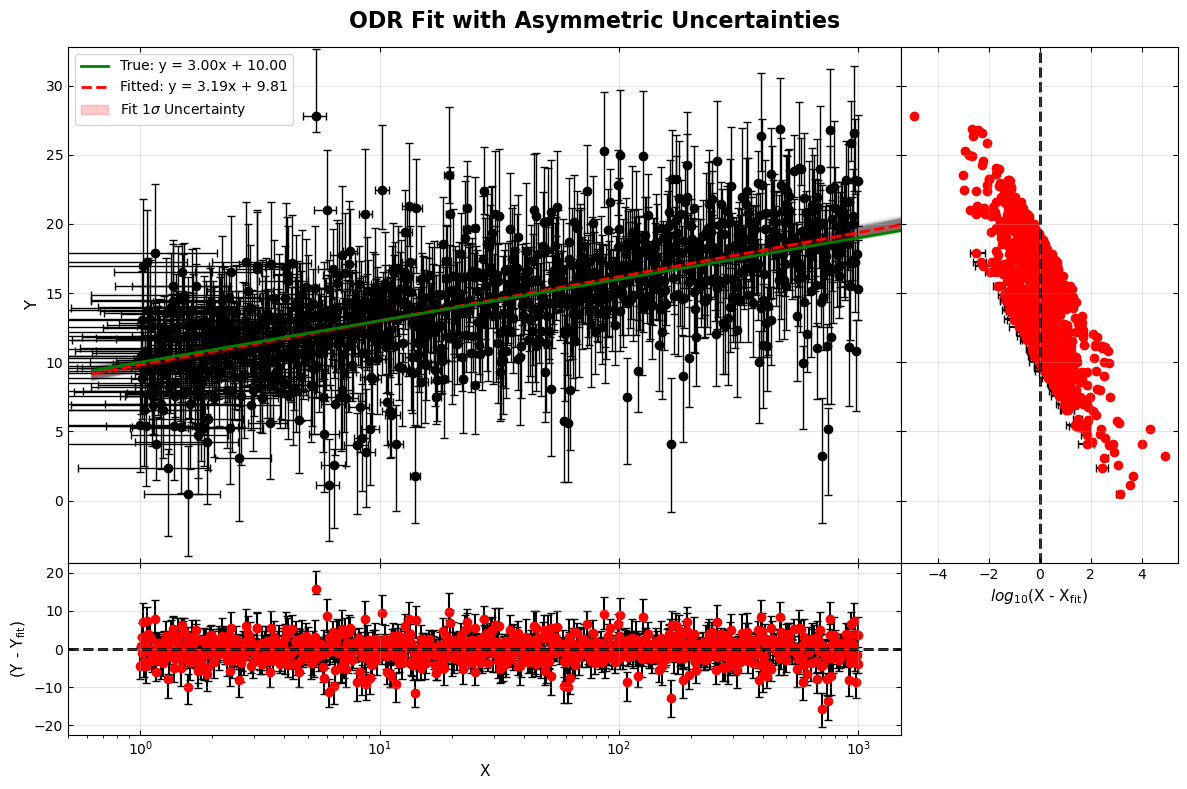

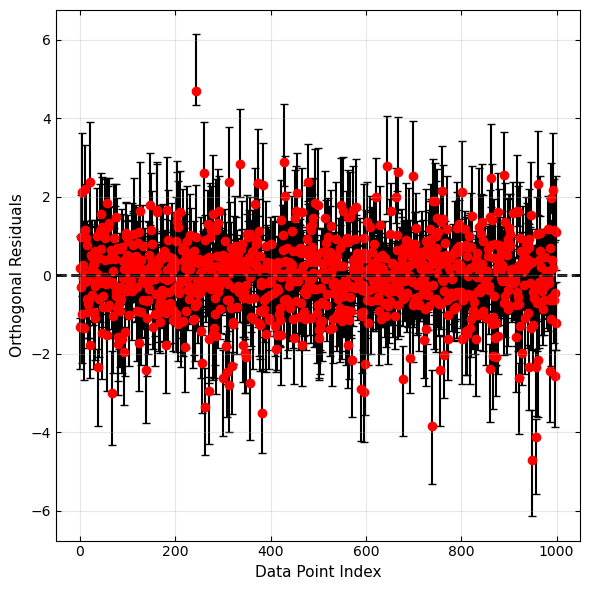

In [7]:
# Plot synthetic data, fit, and residuals
test_figure1 = True
test_figure2 = True

## Figure 1
if test_function and test_figure1:
    fig = plt.figure(figsize=(12, 8))
    fig.suptitle('ODR Fit with Asymmetric Uncertainties', fontsize=16, fontweight='bold')
    gs = fig.add_gridspec(2, 2, hspace=0, wspace=0, width_ratios=[3, 1], height_ratios=[3, 1])

    if semilog_data:
        xlim = (x_test.min() * 0.5, x_test.max() * 1.5)
        ylim = (y_test.min() - 5, y_test.max() + 5)
    else:
        xlim = (x_test.min() - 1, x_test.max() + 1)
        ylim = (y_test.min() - 5, y_test.max() + 5)

    ## Panel 1: Main fit plot
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.set_xscale('log' if semilog_data else 'linear')
    ax1.errorbar(
        x_test, y_test, 
        xerr=[x_test_unc_lower, x_test_unc_upper], 
        yerr=[y_test_unc_lower, y_test_unc_upper], 
        fmt='o', color='k', ecolor='k', elinewidth=1, capsize=3, markersize=6
    )
    ax1.plot(
        x_fit, y_true_line, 
        color='green', linestyle='-', linewidth=2, 
        label=f'True: y = {true_slope:.2f}x + {true_intercept:.2f}', zorder=6)
    for y_boot in y_fits: #[::int(n_iterations*0.5)]:  # Plot bootstrap samples
        ax1.plot(x_fit, y_boot, color='gray', linestyle='-', alpha=0.05, zorder=-1)
    ax1.plot(
        x_fit, y_fit, 
        color='red', linestyle='--', linewidth=2, zorder=5,
        label=f'Fitted: y = {median_coeffs[0]:.2f}x + {median_coeffs[1]:.2f}'
    )
    ax1.fill_between(
        x_fit, y_lower, y_upper, 
        color='red', alpha=0.2, zorder=4,
        label=r'Fit 1$\sigma$ Uncertainty'
    )
    ax1.legend(loc='best', fontsize=10)
    ax1.set_xlim(xlim)
    ax1.set_xticklabels([])  # Hide x-axis labels for top panel
    ax1.set_ylabel('Y', fontsize=12)
    ax1.set_ylim(ylim)
    ax1.grid(True, alpha=0.3)
    ax1.set_frame_on(True)
    ax1.tick_params(direction='in', top=True, right=True)

    ## Panel 2: X Residuals plot
    ax2 = fig.add_subplot(gs[0, 1])
    # ax2.set_xscale('log' if semilog_data else 'linear')
    ax2.errorbar(
        x_residuals_median, y_test,  
        xerr=[x_unc_lower_fit, x_unc_upper_fit], 
        fmt='o', color='red', ecolor='k', capsize=3, zorder=0
    )
    ax2.axvline(0, color='black', linestyle='--', linewidth=2, zorder=1)
    ax2.set_xlabel(r'$log_{10}$(X - X$_{\rm fit}$)', fontsize=11)
    ax2.set_ylim(ylim)
    ax2.set_yticklabels([])  # Hide y-axis labels for right panel
    ax2.grid(True, alpha=0.3)
    ax2.set_frame_on(True)
    ax2.tick_params(direction='in', top=True, right=True)

    ## Panel 3: Y Residuals plot
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.set_xscale('log' if semilog_data else 'linear')
    ax3.errorbar(
        x_test, y_residuals_median,
        yerr=[y_test_unc_lower, y_test_unc_upper], 
        fmt='o', color="red", ecolor='k', capsize=3, zorder=0
    )
    ax3.axhline(0, color='black', linestyle='--', linewidth=2, zorder=1)
    ax3.set_xlabel('X', fontsize=11)
    ax3.set_xlim(xlim)
    ax3.set_ylabel(r'(Y - Y$_{\rm fit}$)', fontsize=11)
    ax3.grid(True, alpha=0.3)
    ax3.set_frame_on(True)
    ax3.tick_params(direction='in', top=True, right=True)

    plt.tight_layout()
    plt.show()

## Figure 2: Plot the orthogonal residuals
if test_function and test_figure2:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_yscale('linear')
    ax.errorbar(
        range(len(orthogonal_residuals)), orthogonal_residuals,
        yerr=[ortho_unc_lower, ortho_unc_upper],
        fmt='o', color='red', ecolor='k', capsize=3, zorder=0
    )
    ax.axhline(0, color='black', linestyle='--', linewidth=2, zorder=1)
    ax.set_xlabel('Data Point Index', fontsize=11)
    ax.set_ylabel('Orthogonal Residuals', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_frame_on(True)
    ax.tick_params(direction='in', top=True, right=True)

    plt.tight_layout()
    plt.show()
